In [1]:
# Import package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import igraph
import scvelo as scv
import loompy as lmp
import anndata as ad
import harmonypy as hm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

import celltypist
from celltypist import models
from celltypist.models import Model

/home/jaehyunchoi/.conda/envs/test02/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/test02/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/test02/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/test02/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/jaehyunchoi/.conda/envs/test02/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarn

In [2]:
adata_IPF= sc.read("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/revision/Data/public_data/Lung_public_atlas_002.h5ad")
adata_IPF

AnnData object with n_obs × n_vars = 385988 × 20551
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample', 'state', 'journal', 'Age', 'celltypist_IPF'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'journal_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata_raw= sc.read("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/revision/Data/public_data/Lung_public_atlas_001.h5ad")
adata_raw

AnnData object with n_obs × n_vars = 385988 × 20551
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample', 'state', 'journal', 'Age', 'Gender'

In [4]:
adata_raw.obs['celltypist_IPF'] = adata_IPF.obs['celltypist_IPF']

In [5]:
adata_CD4 = adata_raw[adata_raw.obs['celltypist_IPF'].isin(['T_CD4','T_Regulatory'])].copy()

In [45]:
adata_CD4.write("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/revision/Data/public_data/Lung_public_CD4_raw.h5ad")

In [10]:
adata_CD4

AnnData object with n_obs × n_vars = 13487 × 20551
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample', 'state', 'journal', 'celltypist_IPF', 'Age', 'Gender'

[[ 7.863539   -0.22310251  3.9820542  -3.313828   -5.2795434 ]
 [ 8.698864    0.47810653  9.551263    2.723116   -7.169353  ]
 [ 7.611443   -2.1066992   4.060829   -2.4330506  -5.6994176 ]
 [ 7.382556   -0.05421673  4.331612   -4.412174   -6.2539563 ]
 [ 7.504383   -2.3719182   1.8533171  -2.958505   -3.6286983 ]]


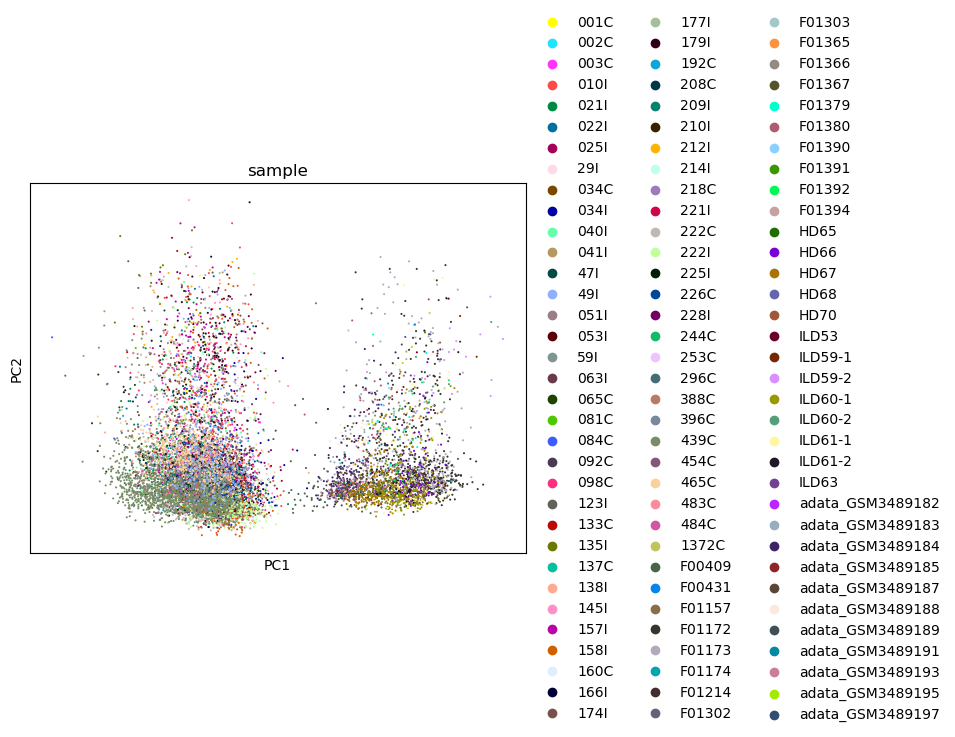

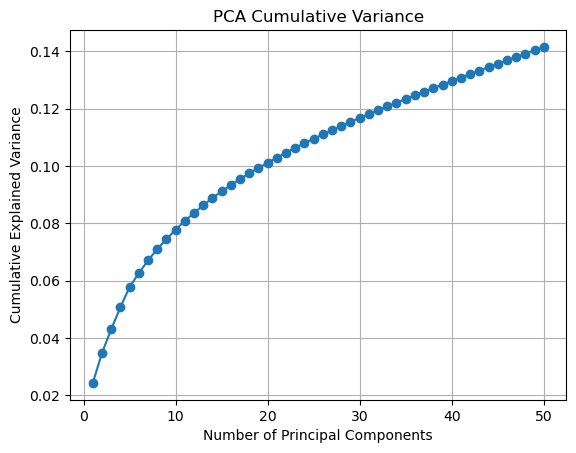

In [11]:
sc.pp.normalize_total(adata_CD4, target_sum=1e4)
sc.pp.log1p(adata_CD4)

sc.pp.highly_variable_genes(adata_CD4, flavor='seurat', n_top_genes=2000)

sc.pp.scale(adata_CD4, max_value=10)
# Run PCA
sc.tl.pca(adata_CD4, svd_solver='arpack')
print(adata_CD4.obsm['X_pca'][:5, :5])
sc.pl.pca(adata_CD4, color='sample')

import matplotlib.pyplot as plt
var_ratio = adata_CD4.uns['pca']['variance_ratio']
plt.plot(range(1, len(var_ratio) + 1), np.cumsum(var_ratio), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Variance')
plt.grid(True)
plt.show()

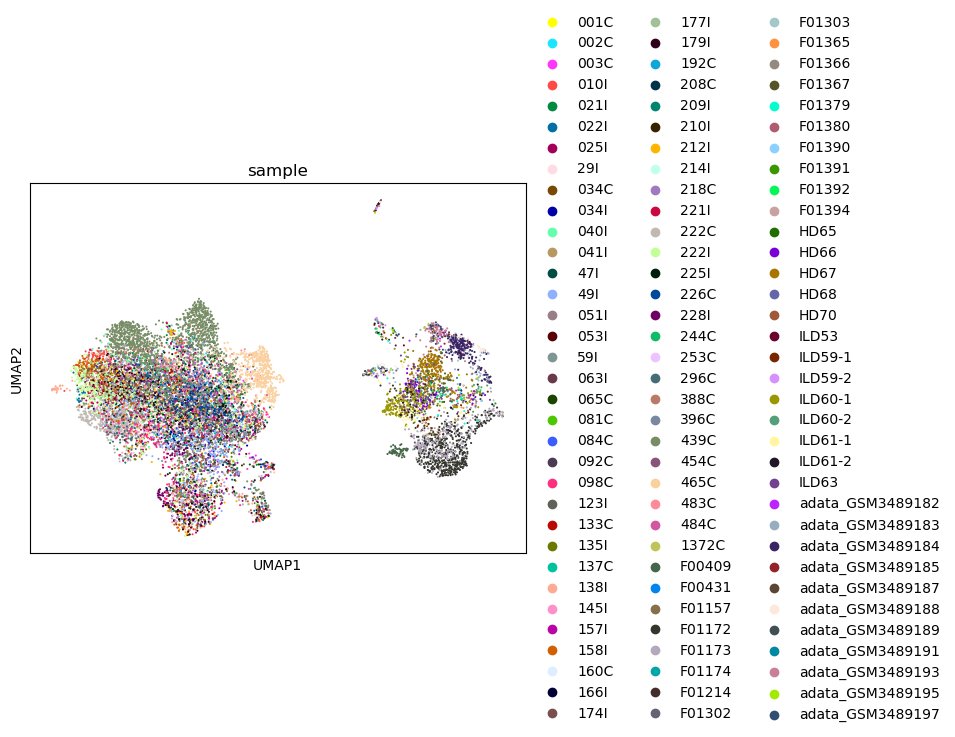

In [12]:
# t-sne 
sc.tl.tsne(adata_CD4, use_rep='X_pca', n_pcs=30)
# umap
sc.pp.neighbors(adata_CD4, n_pcs=30, use_rep='X_pca')
sc.tl.umap(adata_CD4)
sc.pl.umap(adata_CD4, color=['sample'])

2025-11-17 11:47:23,162 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
Computing initial centroids with sklearn.KMeans...
2025-11-17 11:47:38,245 - harmonypy - INFO - sklearn.KMeans initialization complete.
sklearn.KMeans initialization complete.
2025-11-17 11:47:38,423 - harmonypy - INFO - Iteration 1 of 10
Iteration 1 of 10
2025-11-17 11:47:43,010 - harmonypy - INFO - Iteration 2 of 10
Iteration 2 of 10
2025-11-17 11:47:49,366 - harmonypy - INFO - Converged after 2 iterations
Converged after 2 iterations


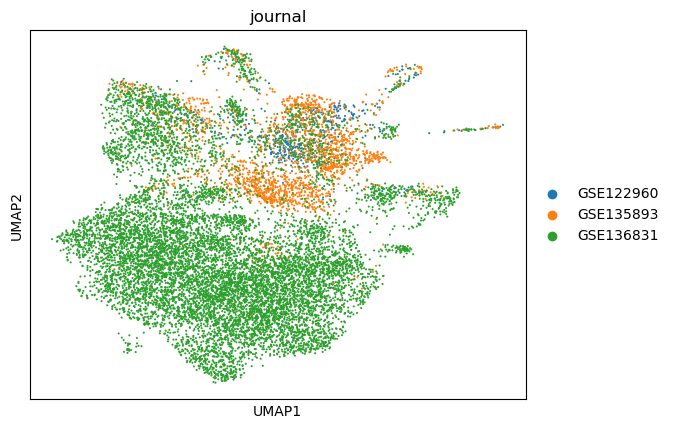

In [13]:
# Harmony
harmony_out = hm.run_harmony(adata_CD4.obsm['X_pca'],adata_CD4.obs, 'journal')
adata_CD4.obsm['X_pca_harmony'] = harmony_out.Z_corr.T


sc.pp.neighbors(adata_CD4, use_rep='X_pca_harmony')  # Harmony 결과를 사용
sc.tl.umap(adata_CD4)
sc.pl.umap(adata_CD4, color=['journal'])

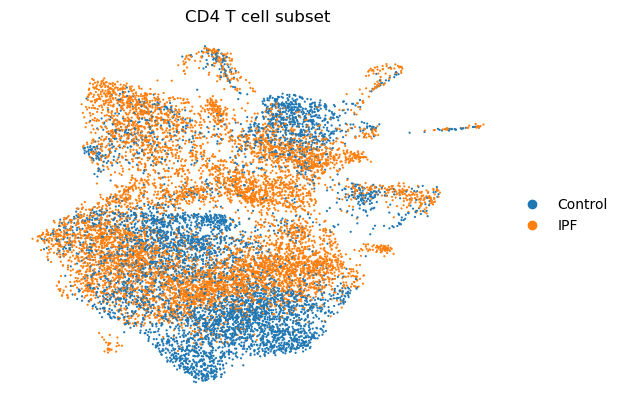

In [14]:
sc.pl.umap(
    adata_CD4,
    color='state',
    frameon=False,
    title='CD4 T cell subset',
    size=10
)

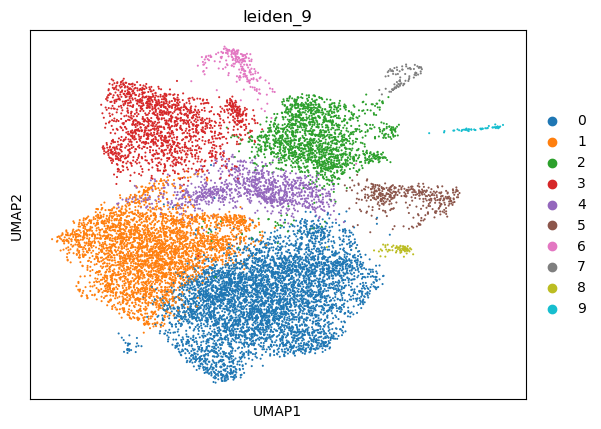

In [15]:
sc.tl.leiden(adata_CD4, resolution=0.27, key_added="leiden_9")
sc.pl.umap(adata_CD4, color=['leiden_9'])

In [16]:
adata_CD4.uns['leiden_9_colors']=['#1f77b4','#17becf', '#279e68','#aa40fc', '#d62728', '#8c564b',
       '#e377c2', '#b5bd61','#ff7f0e', '#aec7e8', '#ffbb78', '#98df8a'] 

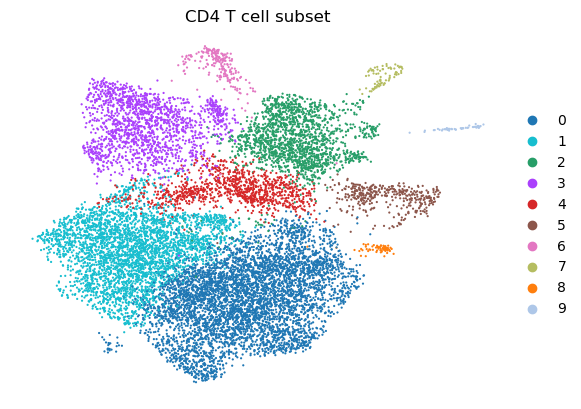

In [17]:
sc.pl.umap(
    adata_CD4,
    color='leiden_9',
    frameon=False,
    title='CD4 T cell subset',
    size=10
)

In [19]:
adata_CD4.write("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/revision/Data/public_data/Lung_public_CD4_001.h5ad")

In [20]:
adata_CD4 = adata_CD4[adata_CD4.obs['Age'] >= 54].copy()
adata_CD4

AnnData object with n_obs × n_vars = 11376 × 20551
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample', 'state', 'journal', 'celltypist_IPF', 'Age', 'Gender', 'leiden_9'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'sample_colors', 'tsne', 'neighbors', 'umap', 'journal_colors', 'state_colors', 'leiden_9'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [27]:
import pandas as pd

umap_df = pd.DataFrame(
    adata_CD4.obsm['X_umap'],
    columns=['UMAP1', 'UMAP2'],
    index=adata_CD4.obs.index  
)
umap_df['leiden_9'] = adata_CD4.obs['leiden_9']

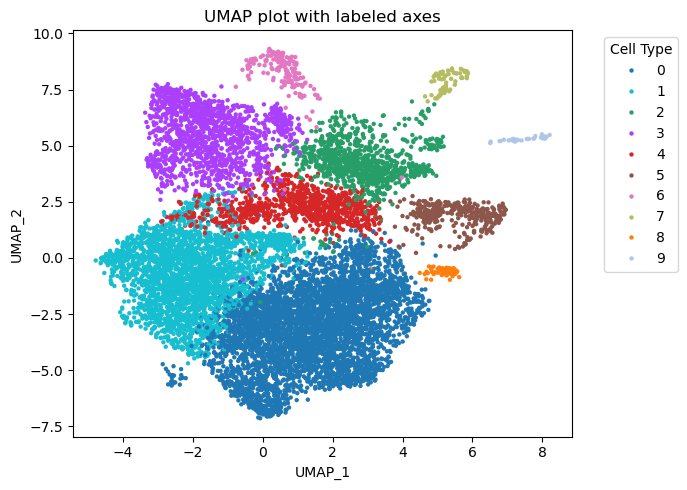

In [30]:
plt.figure(figsize=(7, 5))
custom_palette = adata_CD4.uns['leiden_9_colors']
# 클러스터별 색상 시각화
sns.scatterplot(
    data=umap_df,
    x='UMAP1', y='UMAP2',
    hue='leiden_9',
    palette=custom_palette,
    s=10,
    linewidth=0
)

# 축 레이블 및 눈금 설정
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10) 
plt.title("UMAP plot with labeled axes", fontsize=12)

plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

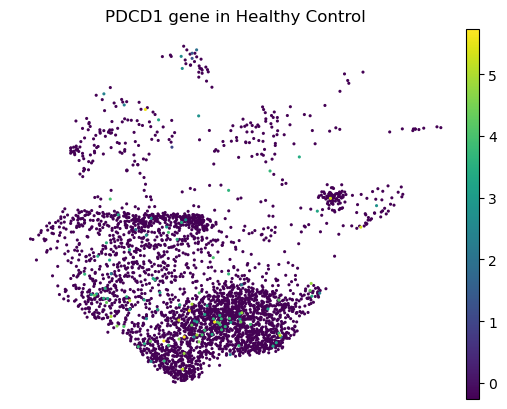

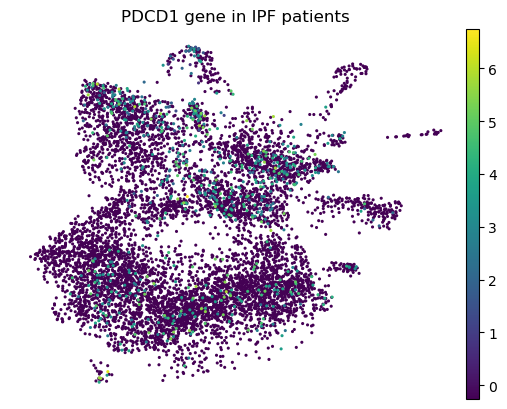

In [40]:
sc.pl.umap(
    adata_CD4[adata_CD4.obs['state'] == 'Control'],
    color='PDCD1',
    frameon=False,
    title='PDCD1 gene in Healthy Control',
    size=20
)
sc.pl.umap(
    adata_CD4[adata_CD4.obs['state'] == 'IPF'],
    color='PDCD1',
    frameon=False,
    title='PDCD1 gene in IPF patients',
    size=20
)

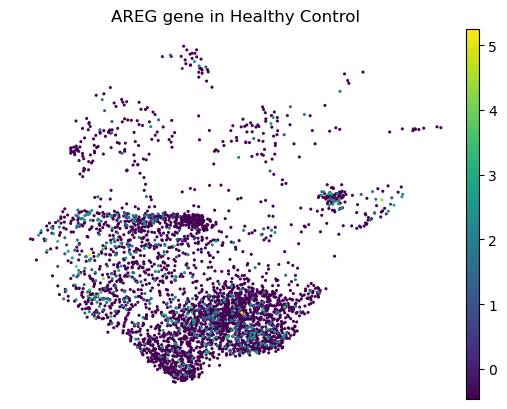

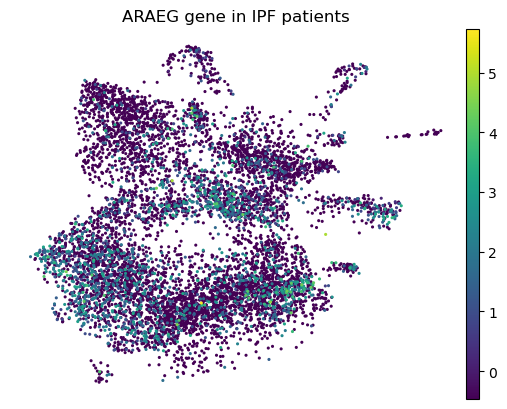

In [41]:
sc.pl.umap(
    adata_CD4[adata_CD4.obs['state'] == 'Control'],
    color='AREG',
    frameon=False,
    title='AREG gene in Healthy Control',
    size=20
)
sc.pl.umap(
    adata_CD4[adata_CD4.obs['state'] == 'IPF'],
    color='AREG',
    frameon=False,
    title='ARAEG gene in IPF patients',
    size=20
)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

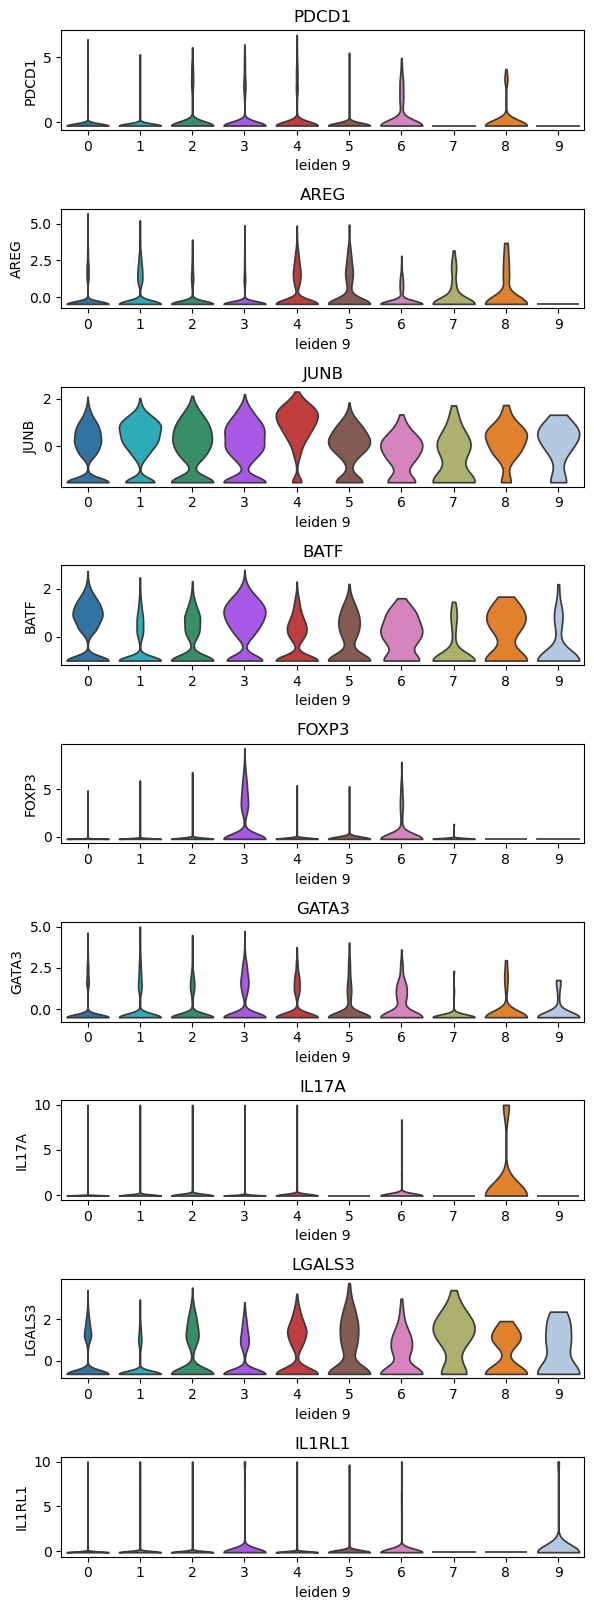

In [31]:
genes = ['PDCD1', 'AREG', 'JUNB', 'BATF', 'FOXP3', 'GATA3', 'IL17A', 'LGALS3','IL1RL1'] 
n_genes = len(genes)
palette = adata_CD4.uns['leiden_9_colors']
fig, axs = plt.subplots(n_genes, 1, figsize=(6, 1.8 * n_genes))


if n_genes == 1:
    axs = [axs]

for i, gene in enumerate(genes):
    sc.pl.violin(
        adata_CD4,
        keys=gene,
        groupby='leiden_9',
        ax=axs[i],
        palette = palette,
        show=False,
        stripplot=False,
        jitter=False
    )
    axs[i].set_title(gene)

plt.tight_layout()

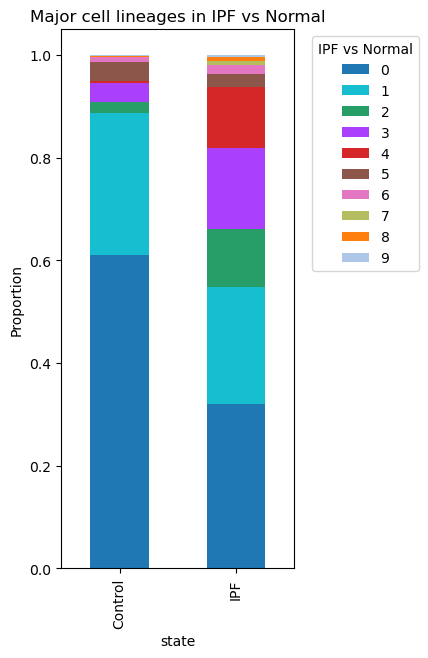

In [32]:
# Make Stacked bargraph for the comparison of cluster compositions
cluster_labels = adata_CD4.obs['leiden_9']
batch_labels = adata_CD4.obs['state']
colors = adata_CD4.uns['leiden_9_colors']
crosstab = pd.crosstab(batch_labels, cluster_labels, normalize='index')

import seaborn as sns
import matplotlib.pyplot as plt

crosstab.plot(kind='bar', stacked=True, figsize=(3, 7), color = colors)  # color=... 도 추가 가능

plt.title('Major cell lineages in IPF vs Normal')
plt.ylabel('Proportion')
plt.xlabel('state')
plt.legend(title='IPF vs Normal', bbox_to_anchor=(1.05, 1), loc='upper left')

In [34]:
from scipy.stats import fisher_exact
import pandas as pd


state = adata_CD4.obs['state']
cluster = adata_CD4.obs['leiden_9']
clusters = cluster.unique()
results = []


for clus in sorted(clusters, key=int):  
    donor_in = ((state == "Control") & (cluster == clus)).sum()
    donor_out = ((state == "Control") & (cluster != clus)).sum()
    ipf_in = ((state == "IPF") & (cluster == clus)).sum()
    ipf_out = ((state == "IPF") & (cluster != clus)).sum()
    
    table = [[donor_in, donor_out], [ipf_in, ipf_out]]
    oddsratio, pval = fisher_exact(table)
    
    donor_frac = donor_in / (donor_in + donor_out)
    ipf_frac = ipf_in / (ipf_in + ipf_out)
    
    results.append({
        "cluster": clus,
        "donor_fraction": donor_frac,
        "ipf_fraction": ipf_frac,
        "odds_ratio": oddsratio,
        "p_value": pval
    })


df_result = pd.DataFrame(results)
df_result = df_result.sort_values("p_value")
print(df_result)

df_result['cluster'] = df_result['cluster'].astype(int)
df_result = df_result.sort_values('cluster')


  cluster  donor_fraction  ipf_fraction  odds_ratio        p_value
0       0        0.611095      0.320315    3.334227  1.742781e-185
4       4        0.004267      0.118433    0.031901  2.276288e-132
3       3        0.036415      0.157995    0.201403   2.115754e-90
2       2        0.022475      0.113090    0.180314   1.253106e-70
8       8        0.000284      0.008269    0.034132   1.187699e-09
1       1        0.275391      0.227834    1.288070   5.846202e-08
7       7        0.001422      0.007633    0.185209   1.003539e-05
6       6        0.008819      0.017555    0.497955   2.829117e-04
5       5        0.036984      0.025696    1.456148   1.359928e-03
9       9        0.002845      0.003180    0.894265   8.561023e-01


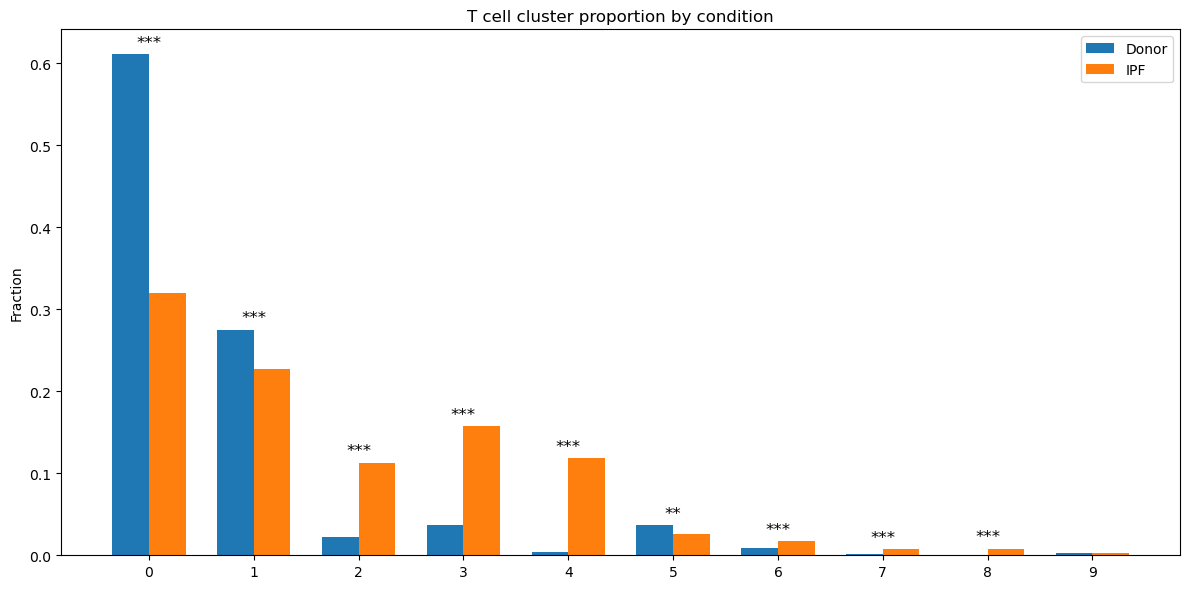

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
x = np.arange(len(df_result))
width = 0.35

# Bar plot
plt.bar(x - width/2, df_result['donor_fraction'], width, label='Donor')
plt.bar(x + width/2, df_result['ipf_fraction'], width, label='IPF')
plt.xticks(x, df_result['cluster'])
plt.ylabel('Fraction')
plt.title('T cell cluster proportion by condition')
plt.legend()


for i, pval in enumerate(df_result['p_value']):
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    else:
        stars = ''
    
    if stars:
        max_height = max(df_result['donor_fraction'][i], df_result['ipf_fraction'][i])
        plt.text(x[i], max_height + 0.005, stars, ha='center', va='bottom', fontsize=12, color='black')

plt.tight_layout()
plt.show()

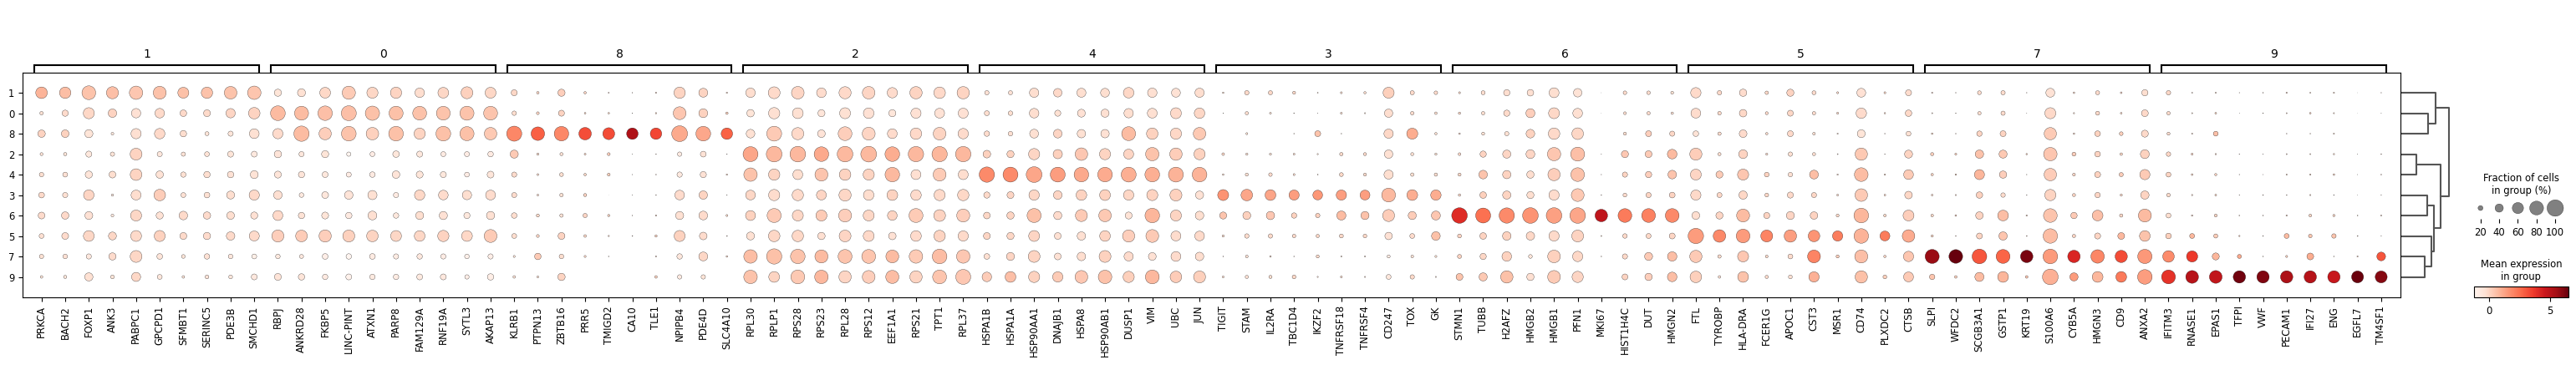

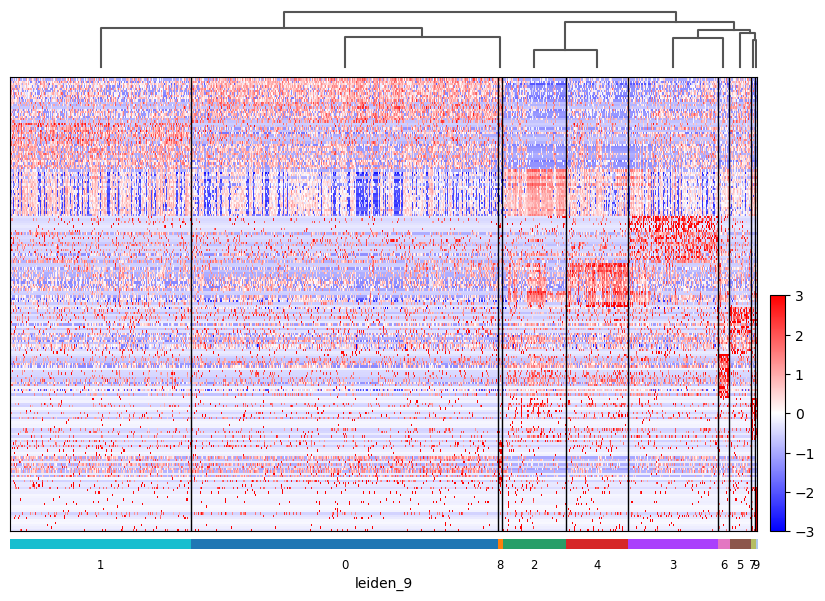

In [36]:
sc.tl.dendrogram(adata_CD4,groupby='leiden_9')
sc.tl.rank_genes_groups(adata_CD4, groupby='leiden_9', method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(adata_CD4, n_genes=10)

rank_df = sc.get.rank_genes_groups_df(adata_CD4, group=None)
top_genes = rank_df.groupby("group")["names"].apply(lambda x: x.head(20)).explode().unique().tolist()
sc.pl.heatmap(
    adata_CD4,
    var_names=top_genes,
    groupby="leiden_9",
    use_raw=False,
    cmap="bwr",
    vmin=-3,
    vmax=3,
    swap_axes=True,
    dendrogram=True,
    show=True,
    figsize=(10, 7)
)

In [37]:
n_cells_per_group = 100
groups = adata_CD4.obs['leiden_9'].unique()
selected_indices = []

for group in groups:
    group_cells = adata_CD4.obs[adata_CD4.obs['leiden_9'] == group].index
    n = min(len(group_cells), n_cells_per_group)  # 그룹 크기가 작을 경우 자동 조절
    sampled = np.random.choice(group_cells, n, replace=False)
    selected_indices.extend(sampled)

adata_sampled = adata_CD4[selected_indices]

<class 'dict'>
dict_keys(['heatmap_ax', 'groupby_ax', 'gene_groups_ax'])


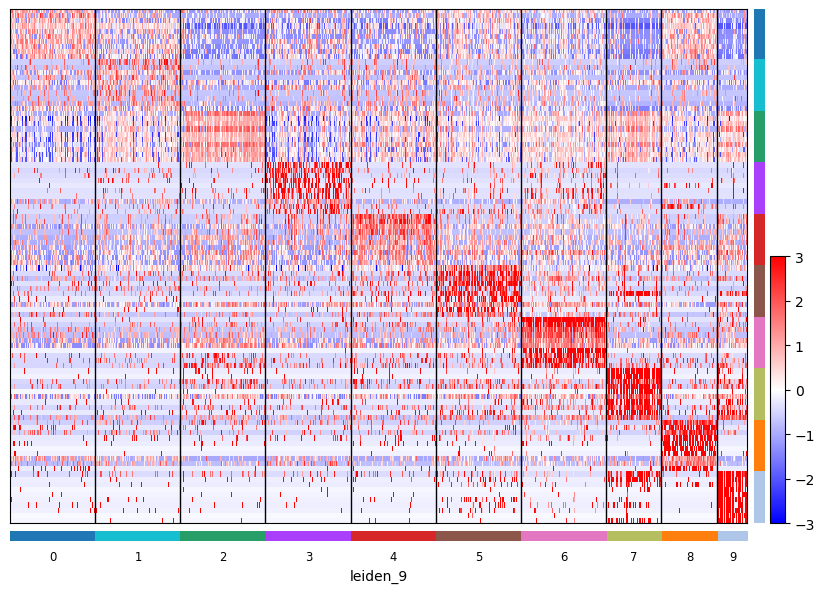

In [38]:
adata_sampled.uns['leiden_9_colors']=['#1f77b4','#17becf', '#279e68','#aa40fc', '#d62728', '#8c564b',
       '#e377c2', '#b5bd61','#ff7f0e', '#aec7e8', '#ffbb78', '#98df8a'] 

fig_dict = sc.pl.rank_genes_groups_heatmap(
    adata_sampled,
    n_genes=10,
    groupby="leiden_9",
    use_raw=False,
    swap_axes=True,
    vmin=-3,
    vmax=3,
    dendrogram=False,
    figsize=(10, 7),
    cmap="bwr",
    show=False,
    show_gene_labels=False,
    return_fig=True
)

print(type(fig_dict))
print(fig_dict.keys())

In [42]:
adata_CD4.write("/home/jaehyunchoi/bystander_collaboration/Figure_script_IPF/revision/Data/public_data/Lung_public_CD4_002.h5ad")